# MC
This notebook shows how to programetically run SWAT with pertubated inputs. It imports from `python_pipeline_scripts`.

## Load environment

In [12]:
import sys; sys.executable

'c:\\Users\\Usuario\\Desktop\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\.venv\\Scripts\\python.exe'

In [13]:
from pathlib import Path
import sys
# Add project root to sys.path for imports
sys.path.insert(0, str(Path().resolve().parent))
from python_pipeline_scripts import utils, runner
from python_pipeline_scripts.provenance_report import write_provenance_reports

# Load config from config.yaml
config = utils.load_config(Path().resolve().parent / 'config' / 'config.yaml')

# Enable autoreload in Jupyter for live code updates
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass  # Not in IPython/Jupyter


# this is were this notebook is located and from where relative paths will be resolved
import os
os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'c:\\Users\\Usuario\\Desktop\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\notebooks'

## monte carlo runs

In [14]:
# Ensure verbose logging for raster aggregation (even when cached)
from python_pipeline_scripts import utils
from pathlib import Path

cfg = utils.load_config(Path("../config/config.yaml"))
# Force INFO/DEBUG as you prefer
cfg.setdefault("logging", {})["level"] = "INFO"

# Initialize module loggers with this config BEFORE invoking the functions
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)

# This makes the function calls of thes scripts emit lines like:
# "Reprojected (cached) -> ..." and "Clipped (cached) -> ..."


<Logger python_pipeline_scripts.transforms.soil_chm (INFO)>

In [15]:
# INPUT PATHS

from pathlib import Path
from python_pipeline_scripts.provenance_report import build_upstream_inputs

#### ADJUST this Path to your local environment. It is used to resolve relative paths here, in the config.yaml and for provenance reporting.
base_dir = Path("../").resolve() #in the original repo, the input_data folder lives next to the code folders # Adjust this to your local environment

# ---------- BASIN info ----------    
hru_zones = r"input_data\Basin info\hru\hru1.shp"
subbasin_zones = r"input_data\Basin info\subbasins\Sub_basin.shp"

# ---------- CHM inputs (SOIL) ----------
## INPUT
chm_raster_folder = r"input_data\Diffuse loads\soil interpolations" 
chm_cross_validation_folder = r"input_data\Diffuse loads\soil interpolations\soil_interpolation_cross_validation_arcgis"

## outputs (intermediate)
output_gpkg = r"input_data\Diffuse loads\python_intermediate_outputs\hru_chem_stats.gpkg"


# ---------- Point loads inputs (WASTE) ----------
## INPUT
pop_raster_folder = r"input_data\Point loads\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES"

## outputs (intermediate)
pop_output_gpkg = r"input_data\Point loads\python_intermediate_outputs\cubillas_population.gpkg"


# ---------- SWAT base + outputs ----------
## INPUT
base_txtinout = r"swat\cubillas\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1"
## outputs (final)
realizations_root = r"outputs\realizations"
results_root = r"outputs\results"





#### ---------- Upstream inputs for provenance ----------
def _resolve(p: str, base: Path) -> Path:
    pp = Path(p)
    resolved = pp if pp.is_absolute() else (base / pp).resolve()

    if not resolved.exists():
        print(f"ERROR: Path does not exist -> {resolved}")

    return resolved

## CHM
output_gpkg_p = _resolve(output_gpkg, base_dir); output_gpkg_p.parent.mkdir(parents=True, exist_ok=True)
chm_raster_folder_p = _resolve(chm_raster_folder, base_dir)
chm_cross_validation_folder_p = _resolve(chm_cross_validation_folder, base_dir)
zones_fp_p = _resolve(hru_zones, base_dir)
manifest_file = Path(str(output_gpkg_p) + ".manifest.json")
chm_csv = str(output_gpkg_p).replace(".gpkg", ".csv")

## Point
pop_raster_folder_p = _resolve(pop_raster_folder, base_dir)
subbasins_fp_p = _resolve(subbasin_zones, base_dir)
pop_output_gpkg_p = _resolve(pop_output_gpkg, base_dir); pop_output_gpkg_p.parent.mkdir(parents=True, exist_ok=True)
point_csv = Path(str(pop_output_gpkg_p).replace(".gpkg", ".csv"))

## SWAT
base_txtinout_p = _resolve(base_txtinout, base_dir)
realizations_root_p = _resolve(realizations_root, base_dir); realizations_root_p.mkdir(parents=True, exist_ok=True)
results_root_p = _resolve(results_root, base_dir); results_root_p.mkdir(parents=True, exist_ok=True)



upstream_chm = build_upstream_inputs(
    raster_folder=chm_raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=zones_fp_p,
    gpkg_path=output_gpkg_p,
    csv_path=Path(chm_csv),
)
upstream_point = [point_csv]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})


# ----------- config ------------------------------
# cfg = utils.load_config(Path("../config/config.yaml"))
cfg = utils.load_config(base_dir / "config" / "config.yaml")


# ---------- Quick sanity prints ----------
print("repo wide config:", cfg)
print("CHM GPKG:", output_gpkg_p)
print("CHM CSV:", chm_csv)
print("Point GPKG:", pop_output_gpkg_p)
print("Point CSV:", point_csv)
print("Base TxtInOut:", base_txtinout_p)
print("Realizations root:", realizations_root_p)
print("Results root:", results_root_p)
print("Manifest (CHM):", manifest_file)


repo wide config: {'logging': {'level': 'INFO', 'log_dir': 'logs', 'file': 'pipeline.log', 'format': '%(asctime)s | %(levelname)s | %(name)s | %(message)s'}, 'paths': {'project_root': '..', 'data_root': 'data', 'outputs_root': 'outputs', 'base_txtinout': '..\\swat\\cubillas\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1', 'swat_executable': '..\\swat\\arcswat\\swat_64rel.exe'}, 'input_groups': {'baseline': {'description': 'Base input data set (recreated)', 'folder': '..\\swat\\cubillas\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1'}}, 'reproducibility': {'random_seed': 12345, 'change_sets': [{'name': 'example_change', 'applies_to_group': 'baseline', 'notes': 'placeholder for documented transformation'}]}, '_base_dir': 'C:\\Users\\Usuario\\Desktop\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\config'}
CHM GPKG: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\python_intermed

## Run input data transformation pipeline (or load from cache)

In [16]:
from pathlib import Path
from typing import List

def find_files_with_string(
    base_path: str,
    search_str: str,
    prefix: str = "",
    remove_substring: str = "",
    file_extension_filter: str | None = None,
) -> List[str]:
    """
    Look for files in base_path whose names contain search_str.
    Optionally restrict the result to a specific file extension, e.g. ".tif".

    Parameters
    ----------
    base_path : str
        The path to search in.
    search_str : str
        The substring to look for in file names (case-sensitive).
    prefix : str, optional
        Prefix to prepend to each matching file name.
    remove_substring : str, optional
        Substring to remove from each matching file name before returning.
    file_extension_filter : str | None, optional
        If provided, only files ending in this extension are included.
        Example: ".tif" or "tif".

    Returns
    -------
    List[str]
        Matching file names with prefix, and with remove_substring removed.
    """
    base = Path(base_path)
    if not base.is_dir():
        raise ValueError(f"{base_path} is not a valid directory")

    ext_filter = file_extension_filter.lower().strip() if file_extension_filter else None
    if ext_filter and not ext_filter.startswith("."):
        ext_filter = "." + ext_filter

    matches = []
    for entry in base.iterdir():
        if not entry.is_file():
            continue
        if search_str not in entry.name:
            continue
        if ext_filter and not entry.name.lower().endswith(ext_filter):
            continue

        name = entry.name
        if remove_substring:
            name = name.replace(remove_substring, "")
        matches.append(prefix + name)

    return matches


path_to_rasters = chm_raster_folder_p

P_raster_interpolation = find_files_with_string(path_to_rasters, "P_", "mean_", remove_substring = ".tif", file_extension_filter = ".tif")[0]
N_raster_interpolation = find_files_with_string(path_to_rasters, "N_", "mean_", remove_substring = ".tif", file_extension_filter = ".tif")[0]
N_raster_interpolation, P_raster_interpolation

('mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample',
 'mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample')

2026-08-17 09:36:19,065 | INFO | notebook.inputs | CHM CSV missing or rebuild=True; running rasterZonalAggregationToGPKG


→ Reading hru shapefile: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Basin info\hru\hru1.shp
✔ Filtered valid hrus: 878 features retained where `HRU_GIS` is not null, empty, or 'NA'.
✔ Reprojected hrus to EPSG:25830
→ Using bounding box for clipping: [ 438912.5        4123462.50012207  470812.5        4158362.50012207]
→ Found 2 raster file(s) matching pattern (case-insensitive)

🔹 Processing raster: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\soil interpolations\N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif → alias: N_prediction_best_according_weight_bias_accuracy_wc_error_resample
→ Raster stats BEFORE clip:
   MIN: 0.04749999940395355, MAX: 1.7711111307144165, MEAN: 0.22466200590133667, SUM: 14852589.0
→ Raster stats AFTER clip:
   MIN: 0.07374999672174454, MAX: 0.4962500035762787, MEAN: 0.1538185328245163, SUM: 1148633.125
→ Plotting raster with hru overlay

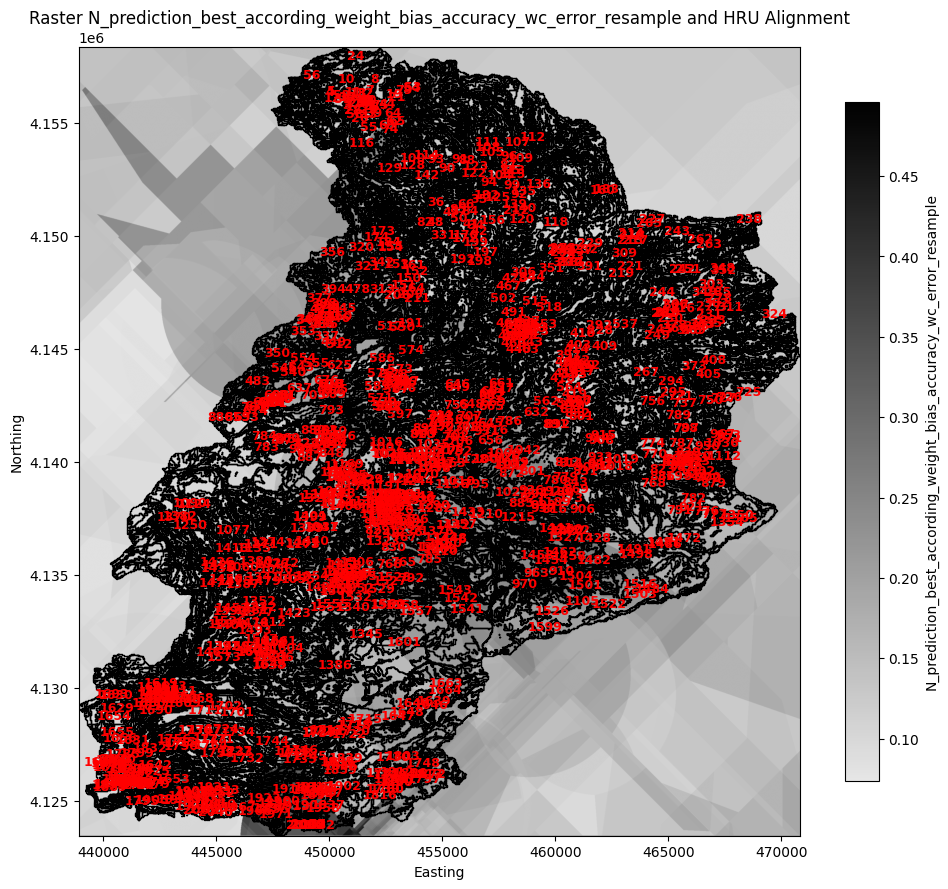

✔ Zonal statistics for mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample:
   HRU 000010061: mean=0.1449578011390006, COUNT=2020, AVG=7.176128769257456e-05
   HRU 000010064: mean=0.13446803669353108, COUNT=910, AVG=0.0001477670732895946
   HRU 000010063: mean=0.13281639099121093, COUNT=350, AVG=0.00037947540283203124
   HRU 000010081: mean=0.13605503142437683, COUNT=3741, AVG=3.6368626416566914e-05
   HRU 000010062: mean=0.14770112586788725, COUNT=2579, AVG=5.7270696342724793e-05
   HRU 000010093: mean=0.1502078978483342, COUNT=3872, AVG=3.879336204760697e-05
   HRU 000010094: mean=0.14854134858039414, COUNT=10377, AVG=1.4314478999748881e-05
   HRU 000010085: mean=0.14298169178523132, COUNT=17378, AVG=8.227741499898223e-06
   HRU 000010082: mean=0.14246861851630518, COUNT=4824, AVG=2.9533295712335237e-05
   HRU 000010100: mean=0.1350346061581925, COUNT=2204, AVG=6.126797012622163e-05
   HRU 000010083: mean=0.13138778440413937, COUNT=620, AVG=0.000211915781296999
  

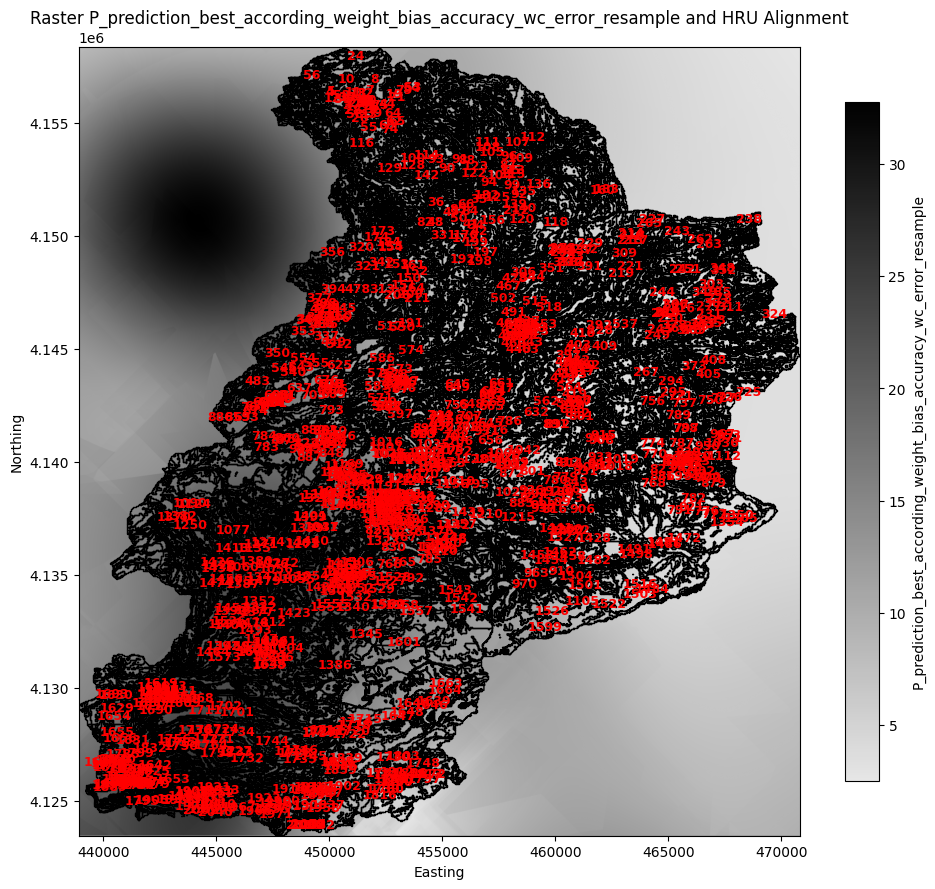

✔ Zonal statistics for mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample:
   HRU 000010061: mean=11.165819345606435, COUNT=2020, AVG=0.005527633339409126
   HRU 000010064: mean=12.08623798076923, COUNT=910, AVG=0.013281580198647506
   HRU 000010063: mean=12.006792689732142, COUNT=350, AVG=0.034305121970663266
   HRU 000010081: mean=12.118338178294573, COUNT=3741, AVG=0.003239331242527285
   HRU 000010062: mean=11.033852904468786, COUNT=2579, AVG=0.0042783454457032905
   HRU 000010093: mean=11.243531282283058, COUNT=3872, AVG=0.0029038045667053353
   HRU 000010094: mean=10.727861195432206, COUNT=10377, AVG=0.0010338114286819126
   HRU 000010085: mean=11.271129445275635, COUNT=17378, AVG=0.0006485861114786302
   HRU 000010082: mean=11.180979056540215, COUNT=4824, AVG=0.0023177817281385188
   HRU 000010100: mean=11.15069015142922, COUNT=2204, AVG=0.005059296801918884
   HRU 000010083: mean=12.435127898185485, COUNT=620, AVG=0.02005665790029917
   HRU 000010086: mean=

2026-08-17 09:38:00,326 | INFO | notebook.inputs | CHM CSV ready: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\python_intermediate_outputs\hru_chem_stats.csv
2026-08-17 09:38:00,333 | INFO | notebook.inputs | Point CSV missing or rebuild=True; building population GPKG/CSV


✔ Done
→ Reading sub-basin shapefile: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Basin info\subbasins\Sub_basin.shp
✔ Reprojected sub-basins to EPSG:25830
→ Using bounding box for clipping: [ 438912.5        4123462.50012207  470812.5        4158362.50012207]

🔹 Processing raster: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Point loads\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES\hipgdac_es_100_1970.tif → year: 1970
→ Reprojecting raster C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Point loads\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES\hipgdac_es_100_1970.tif to EPSG:25830
✔ Reprojected raster saved to C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Point loads\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES\temp_cache\hipgdac_es_100_1970_reproj.tif
→ Raster stats BEFORE clip:
   MIN: 1.0, MAX: 30292.0, MEAN: 40.44963836669922, SUM:

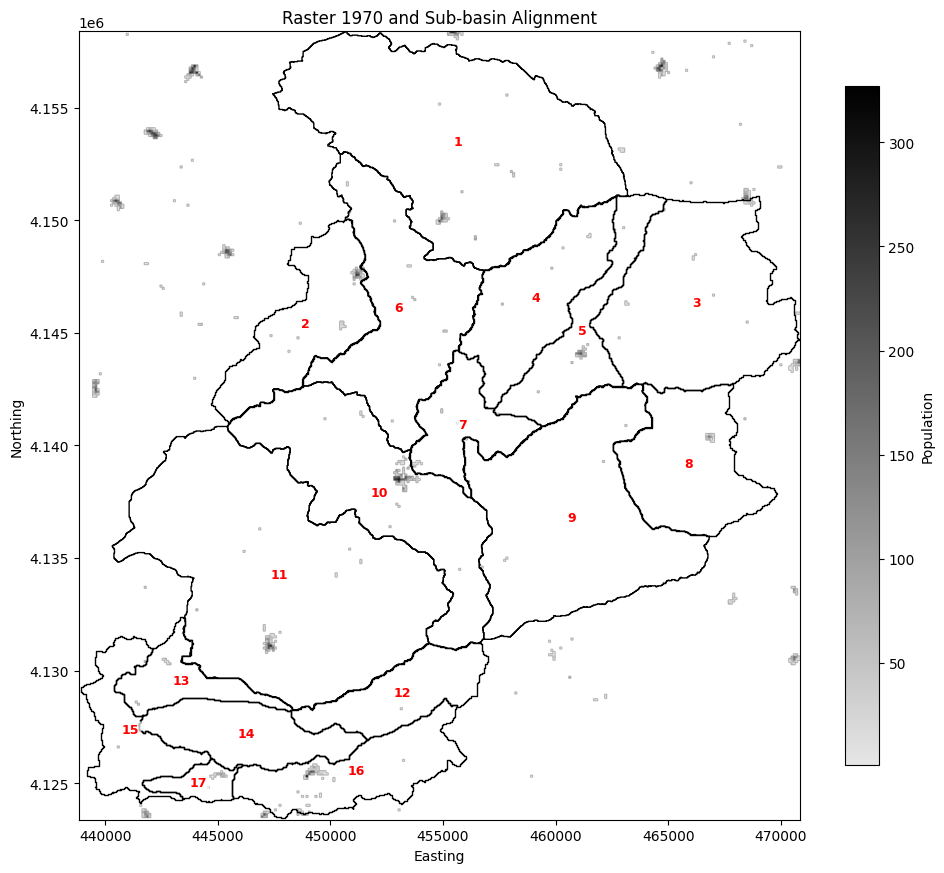

✔ Zonal statistics for popul_sum_1970:
   Zone 1: SUM=1833.0, COUNT=31, AVG=59.12903225806452
   Zone 2: SUM=2176.0, COUNT=36, AVG=60.44444444444444
   Zone 3: SUM=458.0, COUNT=20, AVG=22.9
   Zone 4: SUM=69.0, COUNT=6, AVG=11.5
   Zone 5: SUM=1492.0, COUNT=23, AVG=64.8695652173913
   Zone 6: SUM=305.0, COUNT=13, AVG=23.46153846153846
   Zone 7: SUM=145.0, COUNT=10, AVG=14.5
   Zone 8: SUM=603.0, COUNT=13, AVG=46.38461538461539
   Zone 9: SUM=99.0, COUNT=7, AVG=14.142857142857142
   Zone 10: SUM=4630.0, COUNT=66, AVG=70.15151515151516
   Zone 11: SUM=2667.0, COUNT=45, AVG=59.266666666666666
   Zone 12: SUM=6.0, COUNT=1, AVG=6.0
   Zone 13: SUM=169.0, COUNT=8, AVG=21.125
   Zone 14: SUM=0, COUNT=0, AVG=NA
   Zone 15: SUM=52.0, COUNT=2, AVG=26.0
   Zone 16: SUM=2370.0, COUNT=52, AVG=45.57692307692308
   Zone 17: SUM=533.0, COUNT=14, AVG=38.07142857142857
🔍 Debug: Zone 9 pixel values (non-zero): [ 7. 18.  7.  7. 11. 49. 27. 43. 21.  9.]...
→ Zone 9 pixel count (non-zero): 66, sum: 4630.0


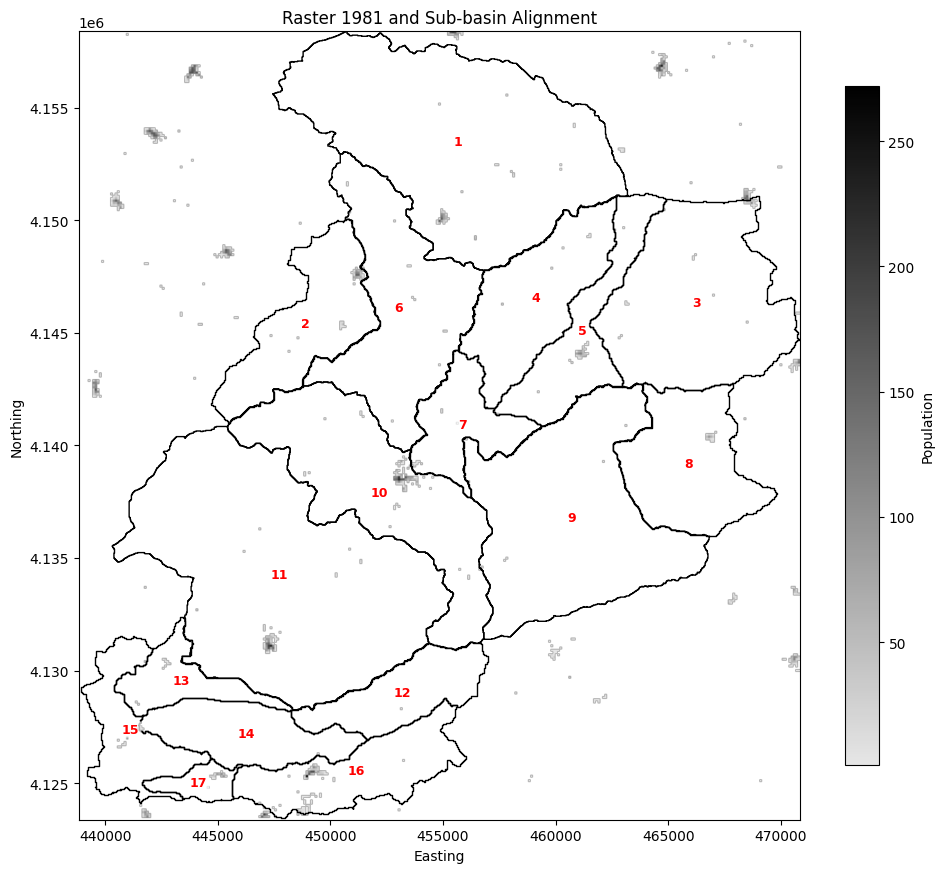

✔ Zonal statistics for popul_sum_1981:
   Zone 1: SUM=1399.0, COUNT=36, AVG=38.861111111111114
   Zone 2: SUM=1439.0, COUNT=36, AVG=39.97222222222222
   Zone 3: SUM=637.0, COUNT=26, AVG=24.5
   Zone 4: SUM=58.0, COUNT=6, AVG=9.666666666666666
   Zone 5: SUM=926.0, COUNT=29, AVG=31.93103448275862
   Zone 6: SUM=165.0, COUNT=13, AVG=12.692307692307692
   Zone 7: SUM=100.0, COUNT=10, AVG=10.0
   Zone 8: SUM=389.0, COUNT=15, AVG=25.933333333333334
   Zone 9: SUM=54.0, COUNT=7, AVG=7.714285714285714
   Zone 10: SUM=3343.0, COUNT=81, AVG=41.27160493827161
   Zone 11: SUM=2446.0, COUNT=53, AVG=46.15094339622642
   Zone 12: SUM=5.0, COUNT=1, AVG=5.0
   Zone 13: SUM=126.0, COUNT=10, AVG=12.6
   Zone 14: SUM=24.0, COUNT=4, AVG=6.0
   Zone 15: SUM=310.0, COUNT=9, AVG=34.44444444444444
   Zone 16: SUM=2176.0, COUNT=71, AVG=30.64788732394366
   Zone 17: SUM=538.0, COUNT=15, AVG=35.86666666666667
🔍 Debug: Zone 9 pixel values (non-zero): [ 4. 10.  4.  8.  6. 26. 15. 79. 11.  5.]...
→ Zone 9 pixel cou

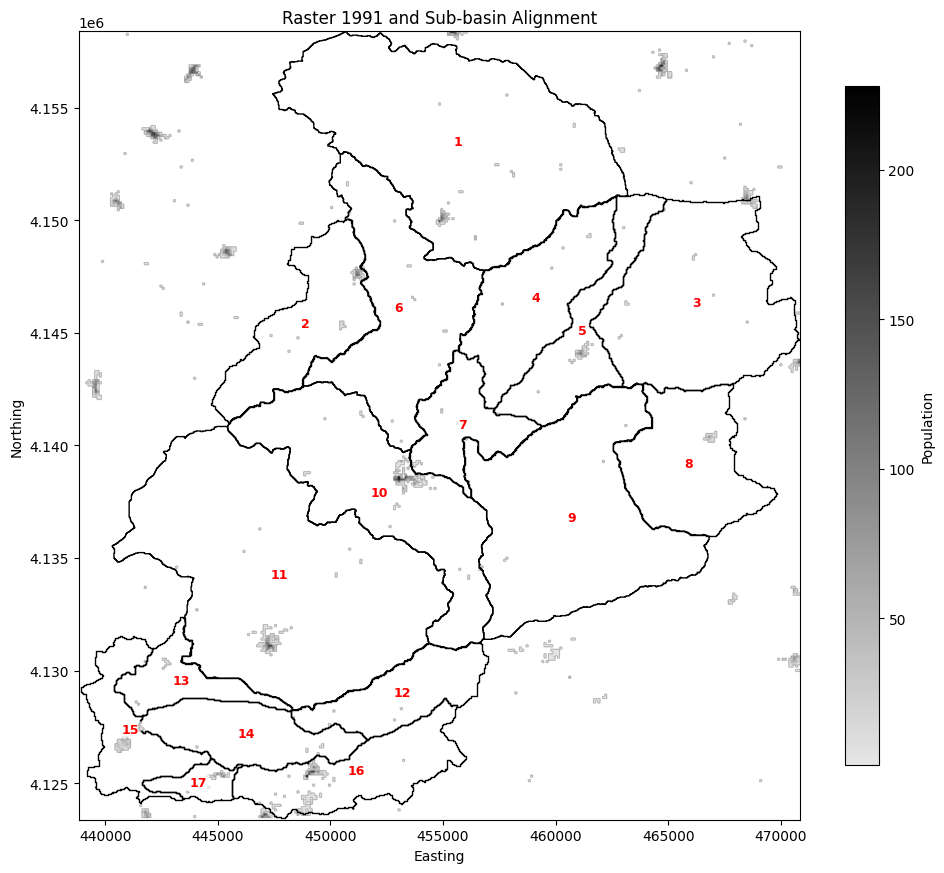

✔ Zonal statistics for popul_sum_1991:
   Zone 1: SUM=1339.0, COUNT=42, AVG=31.88095238095238
   Zone 2: SUM=1241.0, COUNT=36, AVG=34.47222222222222
   Zone 3: SUM=569.0, COUNT=28, AVG=20.321428571428573
   Zone 4: SUM=48.0, COUNT=6, AVG=8.0
   Zone 5: SUM=954.0, COUNT=34, AVG=28.058823529411764
   Zone 6: SUM=126.0, COUNT=14, AVG=9.0
   Zone 7: SUM=77.0, COUNT=10, AVG=7.7
   Zone 8: SUM=420.0, COUNT=19, AVG=22.105263157894736
   Zone 9: SUM=44.0, COUNT=7, AVG=6.285714285714286
   Zone 10: SUM=3503.0, COUNT=105, AVG=33.36190476190476
   Zone 11: SUM=2543.0, COUNT=85, AVG=29.91764705882353
   Zone 12: SUM=16.0, COUNT=5, AVG=3.2
   Zone 13: SUM=91.0, COUNT=10, AVG=9.1
   Zone 14: SUM=55.0, COUNT=10, AVG=5.5
   Zone 15: SUM=1259.0, COUNT=41, AVG=30.70731707317073
   Zone 16: SUM=2404.0, COUNT=98, AVG=24.53061224489796
   Zone 17: SUM=575.0, COUNT=19, AVG=30.263157894736842
🔍 Debug: Zone 9 pixel values (non-zero): [ 3.  7.  3.  6.  5. 20. 11. 70.  9.  8.]...
→ Zone 9 pixel count (non-zero)

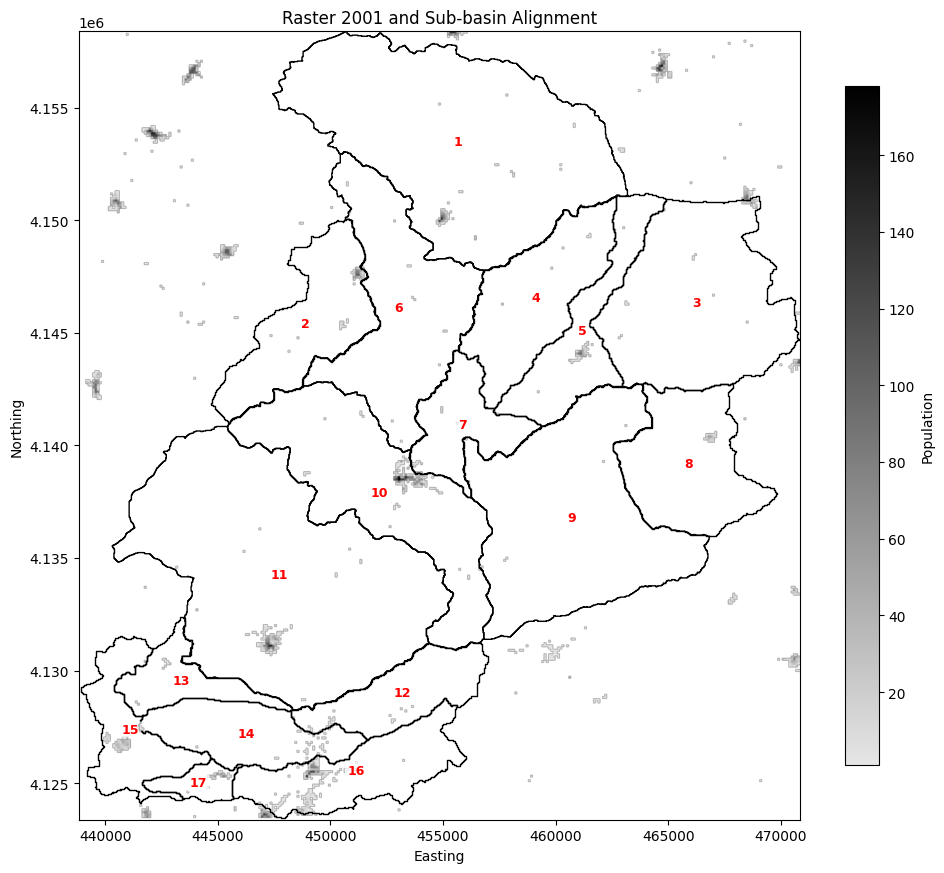

✔ Zonal statistics for popul_sum_2001:
   Zone 1: SUM=1308.0, COUNT=46, AVG=28.434782608695652
   Zone 2: SUM=1152.0, COUNT=40, AVG=28.8
   Zone 3: SUM=548.0, COUNT=28, AVG=19.571428571428573
   Zone 4: SUM=41.0, COUNT=7, AVG=5.857142857142857
   Zone 5: SUM=859.0, COUNT=38, AVG=22.605263157894736
   Zone 6: SUM=108.0, COUNT=14, AVG=7.714285714285714
   Zone 7: SUM=114.0, COUNT=14, AVG=8.142857142857142
   Zone 8: SUM=375.0, COUNT=19, AVG=19.736842105263158
   Zone 9: SUM=36.0, COUNT=7, AVG=5.142857142857143
   Zone 10: SUM=3825.0, COUNT=120, AVG=31.875
   Zone 11: SUM=2614.0, COUNT=102, AVG=25.627450980392158
   Zone 12: SUM=37.0, COUNT=21, AVG=1.7619047619047619
   Zone 13: SUM=77.0, COUNT=10, AVG=7.7
   Zone 14: SUM=123.0, COUNT=41, AVG=3.0
   Zone 15: SUM=1294.0, COUNT=54, AVG=23.962962962962962
   Zone 16: SUM=2530.0, COUNT=160, AVG=15.8125
   Zone 17: SUM=537.0, COUNT=22, AVG=24.40909090909091
🔍 Debug: Zone 9 pixel values (non-zero): [ 2.  6.  3.  5.  4. 17.  9. 59.  7.  7.]...
→

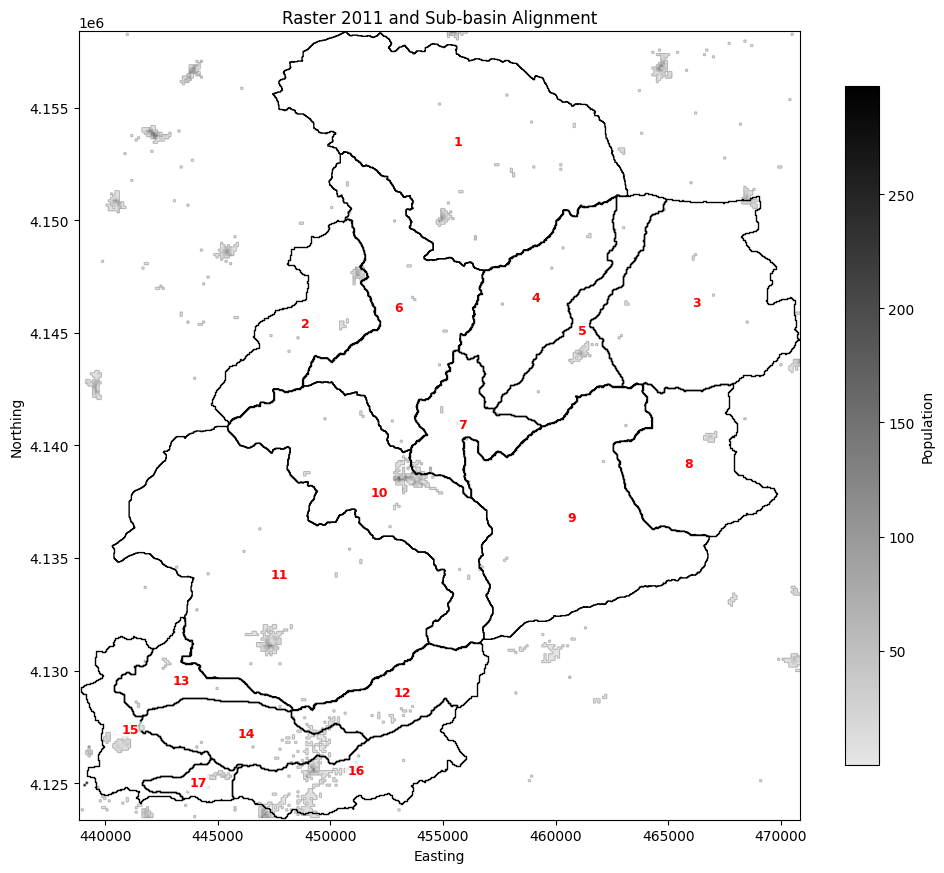

✔ Zonal statistics for popul_sum_2011:
   Zone 1: SUM=1153.0247802734375, COUNT=50, AVG=23.06049560546875
   Zone 2: SUM=1133.5877685546875, COUNT=41, AVG=27.648482159870426
   Zone 3: SUM=462.2452087402344, COUNT=28, AVG=16.50875745500837
   Zone 4: SUM=34.76588439941406, COUNT=7, AVG=4.966554914202009
   Zone 5: SUM=844.3737182617188, COUNT=44, AVG=19.190311778675426
   Zone 6: SUM=90.50732421875, COUNT=14, AVG=6.464808872767857
   Zone 7: SUM=330.7145080566406, COUNT=21, AVG=15.748309907459078
   Zone 8: SUM=336.75372314453125, COUNT=20, AVG=16.837686157226564
   Zone 9: SUM=29.910675048828125, COUNT=7, AVG=4.272953578404018
   Zone 10: SUM=4022.880859375, COUNT=127, AVG=31.67622723917323
   Zone 11: SUM=2687.483154296875, COUNT=118, AVG=22.775280968617583
   Zone 12: SUM=51.766517639160156, COUNT=44, AVG=1.1765117645263672
   Zone 13: SUM=66.39778137207031, COUNT=13, AVG=5.107521644005408
   Zone 14: SUM=147.39202880859375, COUNT=86, AVG=1.7138608000999274
   Zone 15: SUM=1202.5806

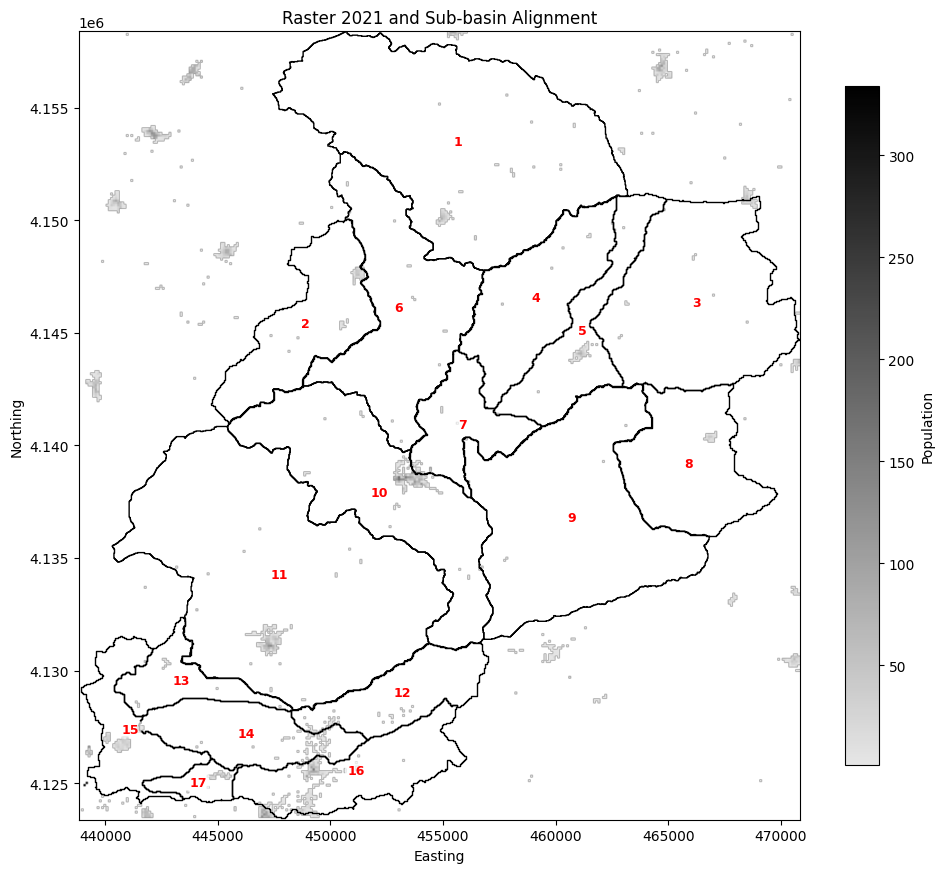

✔ Zonal statistics for popul_sum_2021:
   Zone 1: SUM=819.0, COUNT=50, AVG=16.38
   Zone 2: SUM=722.0, COUNT=41, AVG=17.609756097560975
   Zone 3: SUM=358.0, COUNT=28, AVG=12.785714285714286
   Zone 4: SUM=38.0, COUNT=8, AVG=4.75
   Zone 5: SUM=748.0, COUNT=44, AVG=17.0
   Zone 6: SUM=71.0, COUNT=14, AVG=5.071428571428571
   Zone 7: SUM=381.0, COUNT=21, AVG=18.142857142857142
   Zone 8: SUM=294.0, COUNT=19, AVG=15.473684210526315
   Zone 9: SUM=31.0, COUNT=7, AVG=4.428571428571429
   Zone 10: SUM=4497.0, COUNT=127, AVG=35.40944881889764
   Zone 11: SUM=2727.0, COUNT=121, AVG=22.537190082644628
   Zone 12: SUM=53.0, COUNT=36, AVG=1.4722222222222223
   Zone 13: SUM=71.0, COUNT=13, AVG=5.461538461538462
   Zone 14: SUM=155.0, COUNT=77, AVG=2.012987012987013
   Zone 15: SUM=1291.0, COUNT=56, AVG=23.053571428571427
   Zone 16: SUM=2561.0, COUNT=181, AVG=14.149171270718233
   Zone 17: SUM=529.0, COUNT=24, AVG=22.041666666666668
🔍 Debug: Zone 9 pixel values (non-zero): [ 2.  6.  2.  5.  4. 16

2026-08-17 09:41:10,645 | INFO | notebook.inputs | Point CSV ready: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Point loads\python_intermediate_outputs\cubillas_population.csv


In [17]:
# Inputs + aggregator with rebuild flags (CHM + Point); logs all decisions.
from pathlib import Path
from python_pipeline_scripts import utils
from python_pipeline_scripts.raster_agg import  rasterZonalAggregationToGPKG
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import build_upstream_inputs

# Flags: set True to force (re)create CSVs; set False to use cached CSVs if present
REBUILD_CHM_CSV = False 
REBUILD_POINT_CSV = False

# Ensure module loggers are initialized with your config so cached actions are printed
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)
log = utils.get_logger("notebook.inputs", config=cfg)

def ensure_chm_csv(*, chm_csv: str, raster_folder_p: Path, zones_fp_p: Path, output_gpkg_p: Path, rebuild: bool):
    chm_csv_p = Path(chm_csv)
    if rebuild or not chm_csv_p.exists():
        log.info("CHM CSV missing or rebuild=True; running rasterZonalAggregationToGPKG")
        _ = rasterZonalAggregationToGPKG( #raster_zonal_aggregation_to_gpkg_and_csv(   #raster_zonal_aggregation_to_gpkg(
            raster_folder=chm_raster_folder_p,
            zones_fp=zones_fp_p,
            zone_field="HRU_GIS",
            label_field="OBJECTID",
            output_gpkg=output_gpkg_p,
            files_end_with="_resample.tif",
            stat_operation="mean",
            raster_alias="full_name",
            zone_meaning="HRU",
            overwrite_cache=rebuild,
            #write_manifest=True,
            #config=cfg,
        )
        log.info("CHM CSV ready: %s", chm_csv_p)
    else:
        log.info("Using cached CHM CSV: %s", chm_csv_p)
    return chm_csv_p

def ensure_point_csv(*, point_csv: Path, pop_raster_folder_p: Path, subbasins_fp: Path, pop_output_gpkg_p: Path, rebuild: bool):
    if rebuild or not point_csv.exists():
        try:
            from python_pipeline_scripts.point_dat_builder import subbasinPopulationAggregationToGPKG
            log.info("Point CSV missing or rebuild=True; building population GPKG/CSV")
            _ = subbasinPopulationAggregationToGPKG(
                raster_folder=str(pop_raster_folder_p),
                sub_basin_fp=str(subbasins_fp_p),
                zone_field="GRIDCODE",
                output_gpkg=str(pop_output_gpkg_p),
                overwrite_cache=rebuild,
            )
            if not point_csv.exists():
                raise FileNotFoundError(f"Builder ran but CSV still missing: {point_csv}")
            log.info("Point CSV ready: %s", point_csv)
        except Exception as e:
            log.error("Failed to build point CSV automatically: %s", e)
            raise
    else:
        log.info("Using cached Point CSV: %s", point_csv)
    return point_csv

# Ensure CSVs exist (or rebuild if flags set)
chm_csv_p = ensure_chm_csv(
    chm_csv=chm_csv,
    raster_folder_p=chm_raster_folder_p,
    zones_fp_p=zones_fp_p,
    output_gpkg_p=output_gpkg_p,
    rebuild=REBUILD_CHM_CSV,
)
point_csv_p = ensure_point_csv(
    point_csv=point_csv,
    pop_raster_folder_p=pop_raster_folder_p,
    subbasins_fp=subbasins_fp_p,
    pop_output_gpkg_p=pop_output_gpkg_p,
    rebuild=REBUILD_POINT_CSV,
)

# Upstream inputs for provenance
upstream_chm = build_upstream_inputs(
    raster_folder=chm_raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=hru_zones,
    gpkg_path=output_gpkg_p,
    csv_path=chm_csv_p,
)
upstream_point = [point_csv_p]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})

# Aggregator: logs will show if cached/rebuilt
aggregator = lambda: {
    "chm": read_n_p_means_from_csv_to_df(
        str(chm_csv_p),
        id_col="HRU_GIS",
        n_col=N_raster_interpolation,
        #n_col="N_prediction_best_according_weight_bias_accuracy_wc_error_resample",
        p_col=P_raster_interpolation,
    ),
    "point": normalize_point_year_columns(
        read_population_by_subbasin_csv_to_df(point_csv_p, id_col="GRIDCODE", sep=";"),
        id_col="GRIDCODE",
        debug=False,
    ),
}


### Compare global error/uncerteinty metrics from leave-one-out cross-validation CSV

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

def calculate_uncertainty_measures(csv_path, value_col='Measured', pred_col='Predicted', 
                                   filter_zeros=True, min_measured_value=None, epsilon=1e-10):
    """
    Calculate global uncertainty measures from leave-one-out cross-validation CSV.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing measured and predicted values.
    value_col : str
        Column name for observed values (default: 'Measured').
    pred_col : str
        Column name for predicted values (default: 'Predicted').
    filter_zeros : bool
        If True, remove rows where observed value is 0 (default: True).
    min_measured_value : float or None
        If set, remove rows where observed value is less than or equal to this threshold.
    epsilon : float
        Small value to avoid division by zero in relative error calculation.

    Returns
    -------
    dict
        Dictionary with global uncertainty metrics.
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Optionally remove rows where measured is 0 or below a threshold
    if min_measured_value is not None:
        df = df[df[value_col] > float(min_measured_value)].copy()
    elif filter_zeros:
        df = df[df[value_col] != 0].copy()
    
    if df.empty:
        raise ValueError("No valid rows remain after applying the measured-value filter.")
    
    # Compute relative errors (relative to measured value)
    rel_error = (df[pred_col] - df[value_col]) / (df[value_col] + epsilon)
    abs_rel_error = np.abs(rel_error)
    
    # Compute RMSE-based metrics
    rmse = np.sqrt(np.mean((df[pred_col] - df[value_col])**2))
    obs_range = df[value_col].max() - df[value_col].min()
    obs_mean = df[value_col].mean()
    
    # Compute standard metrics
    metrics = {}
    metrics['File_Name'] = Path(csv_path).name
    
    metrics['RMSE'] = rmse
    metrics['Max_Absolute_Error'] = np.max(np.abs(df[pred_col] - df[value_col]))
    metrics['NRMSE_Range'] = rmse / obs_range if abs(obs_range) > epsilon else np.nan
    metrics['NRMSE_Mean'] = rmse / obs_mean if abs(obs_mean) > epsilon else np.nan
    metrics['Mean_Relative_Error'] = np.mean(rel_error)
    metrics['Mean_Absolute_Relative_Error'] = np.mean(abs_rel_error)
    metrics['Median_Relative_Error'] = np.median(rel_error)
    metrics['Median_Absolute_Relative_Error'] = np.median(abs_rel_error)
    
    metrics['P75_Relative_Error'] = np.percentile(rel_error, 75)
    metrics['P75_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 75)
    
    metrics['P90_Relative_Error'] = np.percentile(rel_error, 90)
    metrics['P90_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 90)
    metrics['Std_Relative_Error'] = np.std(rel_error)
    metrics['Count'] = len(df)
    metrics['Trailing_New_Line'] = "\n"
    
    return metrics

# ------------------------------


def print_uncertainty_results(results):
    for k, v in results.items():
        if k == 'Trailing_New_Line':
            print(v, end="")
        elif isinstance(v, str):
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")


# original P REDIAM interpolation
csv_file_2_point_5 = chm_cross_validation_folder_p / find_files_with_string(chm_cross_validation_folder_p, "P_", "", file_extension_filter = ".csv")[0]
results = calculate_uncertainty_measures(csv_file_2_point_5, filter_zeros=True)
print_uncertainty_results(results)


# # first wrong P REDIAM + LUCAS interpolation
# csv_file_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# results = calculate_uncertainty_measures(csv_file_2, filter_zeros=True)
# print_uncertainty_results(results)

# # second correctly harmonized P REDIAM + LUCAS interpolation
# csv_file_2_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\P_LUCA~2.CSV"  # harmonized version
# results = calculate_uncertainty_measures(csv_file_2_point_2, filter_zeros=True)
# print_uncertainty_results(results)


# original N REDIAM interpolation
csv_file_1_point_5 = chm_cross_validation_folder_p / find_files_with_string(chm_cross_validation_folder_p, "N_", "", file_extension_filter = ".csv")[0]
results = calculate_uncertainty_measures(csv_file_1_point_5, filter_zeros=True)
print_uncertainty_results(results)

# # first wrong N REDIAM + LUCAS interpolation
# csv_file_1 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# results = calculate_uncertainty_measures(csv_file_1, filter_zeros=True)
# print_uncertainty_results(results)

# # second correctly harmonized N REDIAM + LUCAS interpolation
# csv_file_1_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\N_LUCA~2.CSV"  # harmonized version
# results = calculate_uncertainty_measures(csv_file_1_point_2, filter_zeros=True)
# print_uncertainty_results(results)



File_Name: P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 28.6732
Max_Absolute_Error: 136.2862
NRMSE_Range: 0.1491
NRMSE_Mean: 1.0040
Mean_Relative_Error: 24.8744
Mean_Absolute_Relative_Error: 25.2558
Median_Relative_Error: 0.2588
Median_Absolute_Relative_Error: 0.6465
P75_Relative_Error: 2.0311
P75_Absolute_Relative_Error: 2.0311
P90_Relative_Error: 6.7219
P90_Absolute_Relative_Error: 6.7219
Std_Relative_Error: 166.2357
Count: 255.0000

File_Name: N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 0.3821
Max_Absolute_Error: 4.7940
NRMSE_Range: 0.0646
NRMSE_Mean: 1.6072
Mean_Relative_Error: 0.7002
Mean_Absolute_Relative_Error: 0.9509
Median_Relative_Error: 0.2434
Median_Absolute_Relative_Error: 0.4696
P75_Relative_Error: 0.9904
P75_Absolute_Relative_Error: 0.9904
P90_Relative_Error: 1.9578
P90_Absolute_Relative_Error: 1.9578
Std_Relative_Error: 1.8656
Count: 326.0000




=== P soil interpolation ===
Cross-validation count audit


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13052\2660355287.py:129: UserWarning: Error clipping raster P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif: Failed to open dataset (flags=68): input_data\Basin info\hru\hru1.shp
  warnings.warn(f"Error clipping raster {Path(raster_path).name}: {e}")


,Dataset,Total_Rows,Exact_Zero_Count,Near_Zero_Count_LE_0p01,Threshold_Value,Count_Measured_LE_Threshold,Retained_Rows,Removed_Rows,Filter_Rule
0,P soil interpolation,328,73,77,0.001,73,255,73,Measured > 0.001


Field-structure table


,Dataset,Source,Count,Min,Q1,Mean,Median,Q3,Max,IQR,CV,Hotspot_Attenuation_vs_Observed_Max
0,P soil interpolation,Observed points,255,0.0100,6.8800,28.5582,17.5000,38.9650,192.3600,32.0850,1.0899,1.0000
1,P soil interpolation,Interpolated raster (full domain),68491332,-1.0895,12.4658,22.1504,21.0870,30.6972,76.8871,18.2314,0.5969,NaN
2,P soil interpolation,Final HRU averages,878,3.4219,6.0256,11.8921,11.2134,16.7493,26.1189,10.7237,0.5446,0.1358


Leave-one-out error table


,Dataset,Count,Bias,MAE,RMSE,Max_Absolute_Error,Mean_Absolute_Relative_Error,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,P soil interpolation,255,-4.1336,19.2837,28.6732,136.2862,25.2558,0.6465,2.0311,6.7219,18.0392,36.0784,43.5294,41.9608,58.0392,0.8051,0.4124,26.6856,92.9412,1.0738


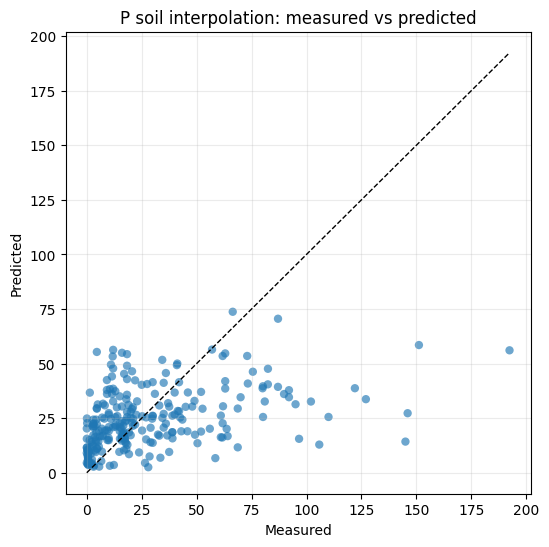


=== N soil interpolation ===
Cross-validation count audit


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13052\2660355287.py:129: UserWarning: Error clipping raster N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif: Failed to open dataset (flags=68): input_data\Basin info\hru\hru1.shp
  warnings.warn(f"Error clipping raster {Path(raster_path).name}: {e}")


,Dataset,Total_Rows,Exact_Zero_Count,Near_Zero_Count_LE_0p01,Threshold_Value,Count_Measured_LE_Threshold,Retained_Rows,Removed_Rows,Filter_Rule
0,N soil interpolation,328,2,2,0.001,2,326,2,Measured > 0.001


Field-structure table


,Dataset,Source,Count,Min,Q1,Mean,Median,Q3,Max,IQR,CV,Hotspot_Attenuation_vs_Observed_Max
0,N soil interpolation,Observed points,326,0.0200,0.0800,0.2378,0.1200,0.190,5.9400,0.1100,1.9706,1.0000
1,N soil interpolation,Interpolated raster (full domain),68491332,0.0000,0.1112,0.2169,0.1618,0.250,1.7711,0.1388,0.9159,NaN
2,N soil interpolation,Final HRU averages,878,0.0958,0.1294,0.1623,0.1591,0.192,0.3366,0.0626,0.2681,0.0567


Leave-one-out error table


,Dataset,Count,Bias,MAE,RMSE,Max_Absolute_Error,Mean_Absolute_Relative_Error,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,N soil interpolation,326,-0.003,0.1474,0.3821,4.794,0.9509,0.4696,0.9904,1.9578,28.8344,53.3742,66.8712,35.5828,64.4172,0.5421,0.579,0.4702,97.8528,0.8197


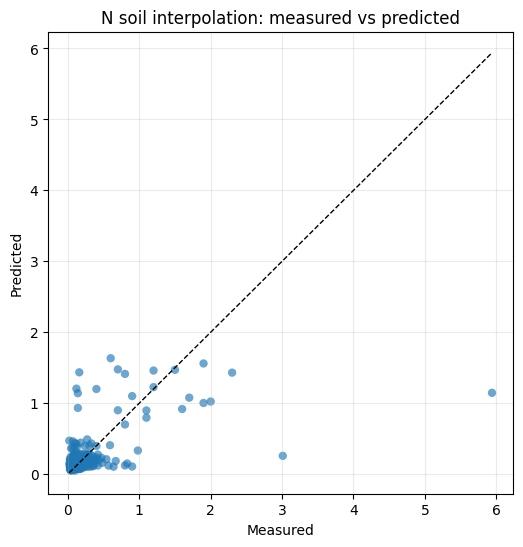

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import rasterio
import rasterio.mask
import fiona
import warnings

def _filter_measured_rows(df, value_col='Measured', filter_zeros=True, min_measured_value=None):
    if min_measured_value is not None:
        threshold = float(min_measured_value)
        return df[df[value_col] > threshold].copy(), f'Measured > {threshold:g}'
    if filter_zeros:
        return df[df[value_col] != 0].copy(), 'Measured != 0'
    return df.copy(), 'No measured-value filter'

def _build_cv_count_audit(csv_path, dataset_label, value_col='Measured', filter_zeros=True, min_measured_value=None):
    raw_df = pd.read_csv(csv_path)
    filtered_df, filter_rule = _filter_measured_rows(
        raw_df,
        value_col=value_col,
        filter_zeros=filter_zeros,
        min_measured_value=min_measured_value,
    )
    threshold_value = 'n/a' if min_measured_value is None else float(min_measured_value)
    threshold_count = 'n/a' if min_measured_value is None else int((raw_df[value_col] <= float(min_measured_value)).sum())
    return pd.DataFrame([
        {
            'Dataset': dataset_label,
            'Total_Rows': int(len(raw_df)),
            'Exact_Zero_Count': int((raw_df[value_col] == 0).sum()),
            'Near_Zero_Count_LE_0p01': int((raw_df[value_col] <= 0.01).sum()),
            'Threshold_Value': threshold_value,
            'Count_Measured_LE_Threshold': threshold_count,
            'Retained_Rows': int(len(filtered_df)),
            'Removed_Rows': int(len(raw_df) - len(filtered_df)),
            'Filter_Rule': filter_rule,
        }
    ])

def _load_cv_diagnostics(csv_path, value_col='Measured', pred_col='Predicted', filter_zeros=True, min_measured_value=None, epsilon=1e-10):
    df = pd.read_csv(csv_path)
    df, _ = _filter_measured_rows(
        df,
        value_col=value_col,
        filter_zeros=filter_zeros,
        min_measured_value=min_measured_value,
    )
    if df.empty:
        raise ValueError('No valid rows remain after applying the measured-value filter.')
    df['Error'] = df[pred_col] - df[value_col]
    df['AbsError'] = df['Error'].abs()
    df['RelError'] = df['Error'] / (df[value_col] + epsilon)
    df['AbsRelError'] = df['RelError'].abs()
    df['Ratio_Predicted_to_Measured'] = df[pred_col] / (df[value_col] + epsilon)
    df['sMAPE'] = 2.0 * df['AbsError'] / (df[pred_col].abs() + df[value_col].abs() + epsilon)
    return df

def _read_hru_field(hru_csv_path, hru_value_col):
    hru_df = pd.read_csv(hru_csv_path, sep=';')
    if hru_value_col not in hru_df.columns:
        raise KeyError(f'Column {hru_value_col!r} not found in {Path(hru_csv_path).name}')
    return hru_df[hru_value_col].astype(float)

def _series_structure(values, dataset_label, source_label, epsilon=1e-10):
    series = pd.Series(values, dtype=float).dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        'Dataset': dataset_label,
        'Source': source_label,
        'Count': int(series.size),
        'Min': float(series.min()),
        'Q1': float(q1),
        'Mean': float(series.mean()),
        'Median': float(series.median()),
        'Q3': float(q3),
        'Max': float(series.max()),
        'IQR': float(q3 - q1),
        'CV': float(series.std(ddof=0) / (series.mean() + epsilon)),
    }

def _load_raster_stats(raster_path, dataset_label, source_label, epsilon=1e-10):
    """Load full raster and compute statistics for non-null values."""
    try:
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            nodata = src.nodata
            # Extract non-null values
            if nodata is not None:
                values = data[~np.isnan(data) & (data != nodata)]
            else:
                values = data[~np.isnan(data)]
            if len(values) == 0:
                warnings.warn(f"No valid pixels in {Path(raster_path).name}; skipping raster stats")
                return None
        return _series_structure(values, dataset_label, source_label, epsilon=epsilon)
    except Exception as e:
        warnings.warn(f"Error loading raster {Path(raster_path).name}: {e}")
        return None

def _load_raster_stats_clipped(raster_path, shapes_path, dataset_label, source_label, epsilon=1e-10):
    """Load raster clipped to shapefile geometries and compute statistics."""
    try:
        with fiona.open(shapes_path, encoding='utf-8') as shapes:
            features = [feature['geometry'] for feature in shapes]
        if not features:
            warnings.warn(f"No geometries found in {Path(shapes_path).name}")
            return None
        with rasterio.open(raster_path) as src:
            try:
                masked_array, _ = rasterio.mask.mask(src, features, crop=True)
            except ValueError as e:
                warnings.warn(f"Clipping failed (no intersection?): {e}; skipping clipped raster stats")
                return None
            data = masked_array[0]
            nodata = src.nodata
            if nodata is not None:
                values = data[~np.isnan(data) & (data != nodata)]
            else:
                values = data[~np.isnan(data)]
            if len(values) == 0:
                warnings.warn(f"No valid pixels after clipping {Path(raster_path).name}")
                return None
        return _series_structure(values, dataset_label, source_label, epsilon=epsilon)
    except Exception as e:
        warnings.warn(f"Error clipping raster {Path(raster_path).name}: {e}")
        return None

def _error_summary(cv_df, dataset_label, value_col='Measured', pred_col='Predicted', epsilon=1e-10):
    ratio = cv_df[pred_col] / (cv_df[value_col] + epsilon)
    summary = {
        'Dataset': dataset_label,
        'Count': int(len(cv_df)),
        'Bias': float(cv_df['Error'].mean()),
        'MAE': float(cv_df['AbsError'].mean()),
        'RMSE': float(np.sqrt(np.mean(cv_df['Error'] ** 2))),
        'Max_Absolute_Error': float(cv_df['AbsError'].max()),
        'Mean_Absolute_Relative_Error': float(cv_df['AbsRelError'].mean()),
        'Median_Absolute_Relative_Error': float(cv_df['AbsRelError'].median()),
        'P75_Absolute_Relative_Error': float(cv_df['AbsRelError'].quantile(0.75)),
        'P90_Absolute_Relative_Error': float(cv_df['AbsRelError'].quantile(0.90)),
        'Share_Within_25pct': float(100.0 * (cv_df['AbsRelError'] <= 0.25).mean()),
        'Share_Within_50pct': float(100.0 * (cv_df['AbsRelError'] <= 0.50).mean()),
        'Share_Within_Factor_2': float(100.0 * ((ratio >= 0.5) & (ratio <= 2.0)).mean()),
        'Underprediction_Share': float(100.0 * (cv_df['Error'] < 0).mean()),
        'Overprediction_Share': float(100.0 * (cv_df['Error'] > 0).mean()),
        'sMAPE': float(cv_df['sMAPE'].mean()),
        'Pearson_r': float(cv_df[value_col].corr(cv_df[pred_col])),
    }
    if 'StdError' in cv_df.columns:
        summary['ASE'] = float(cv_df['StdError'].mean())
        summary['Coverage_95pct_pct'] = float(100.0 * (cv_df['AbsError'] <= 1.96 * cv_df['StdError']).mean())
    if 'Stdd_Error' in cv_df.columns:
        summary['RMSSE'] = float(np.sqrt(np.mean(cv_df['Stdd_Error'] ** 2)))
    return pd.DataFrame([summary])

def _find_companion_cv_path(cv_csv_path):
    cv_path = Path(cv_csv_path)
    companion_name = cv_path.name.replace('_REDIAM_', '_LUCAS_AND_REDIAM_')
    companion_path = cv_path.with_name(companion_name)
    return companion_path if companion_path.exists() else None

def _comparison_table(cv_csv_path, dataset_label, filter_zeros=True, min_measured_value=None, epsilon=1e-10):
    tables = []
    primary_df = _load_cv_diagnostics(cv_csv_path, filter_zeros=filter_zeros, min_measured_value=min_measured_value, epsilon=epsilon)
    tables.append(_error_summary(primary_df, f'{dataset_label} | REDIAM', epsilon=epsilon))
    companion_path = _find_companion_cv_path(cv_csv_path)
    if companion_path is not None and companion_path != Path(cv_csv_path):
        companion_df = _load_cv_diagnostics(companion_path, filter_zeros=filter_zeros, min_measured_value=min_measured_value, epsilon=epsilon)
        tables.append(_error_summary(companion_df, f'{dataset_label} | REDIAM + LUCAS', epsilon=epsilon))
    return pd.concat(tables, ignore_index=True)

def display_interpolation_diagnostics(
    cv_csv_path, hru_csv_path, hru_value_col, dataset_label,
    raster_path=None, hru_zones_fp=None,
    show_full_raster=True, show_clipped_raster=True,
    filter_zeros=True, min_measured_value=None, epsilon=1e-10
):
    """
    Display interpolation diagnostics with optional raster statistics.
    
    Parameters
    ----------
    show_full_raster : bool
        Include full raster domain statistics in structure table (default: True)
    show_clipped_raster : bool
        Include raster clipped to HRU zones in structure table (default: True)
    min_measured_value : float or None
        If set, remove rows where Measured is less than or equal to this threshold.
    """
    cv_df = _load_cv_diagnostics(cv_csv_path, filter_zeros=filter_zeros, min_measured_value=min_measured_value, epsilon=epsilon)
    count_audit_table = _build_cv_count_audit(cv_csv_path, dataset_label, filter_zeros=filter_zeros, min_measured_value=min_measured_value)
    hru_values = _read_hru_field(hru_csv_path, hru_value_col)
    observed_max = float(cv_df['Measured'].max())
    
    # Build structure table rows
    rows = [
        _series_structure(cv_df['Measured'], dataset_label, 'Observed points', epsilon=epsilon),
        
    ]
    
    # Add full raster statistics if requested
    if raster_path and show_full_raster:
        raster_stats_full = _load_raster_stats(raster_path, dataset_label, 'Interpolated raster (full domain)', epsilon=epsilon)
        if raster_stats_full is not None:
            rows.append(raster_stats_full)
    
    # Add HRU-clipped raster statistics if requested
    if raster_path and hru_zones_fp and show_clipped_raster:
        raster_stats_clipped = _load_raster_stats_clipped(raster_path, hru_zones_fp, dataset_label, 'Interpolated raster (HRU zones)', epsilon=epsilon)
        if raster_stats_clipped is not None:
            rows.append(raster_stats_clipped)
    

    rows.append(_series_structure(hru_values, dataset_label, 'Final HRU averages', epsilon=epsilon))

    structure_table = pd.DataFrame(rows)
    structure_table.loc[structure_table['Source'] == 'Observed points', 'Hotspot_Attenuation_vs_Observed_Max'] = 1.0
    structure_table.loc[structure_table['Source'] == 'Final HRU averages', 'Hotspot_Attenuation_vs_Observed_Max'] = float(hru_values.max() / (observed_max + epsilon))
    error_table = _error_summary(cv_df, dataset_label, epsilon=epsilon)
    comparison_table = _comparison_table(cv_csv_path, dataset_label, filter_zeros=filter_zeros, min_measured_value=min_measured_value, epsilon=epsilon)

    print(f'\n=== {dataset_label} ===')
    print('Cross-validation count audit')
    display(count_audit_table)
    print('Field-structure table')
    display(structure_table.round(4))
    print('Leave-one-out error table')
    display(error_table.round(4))
    if len(comparison_table) > 1:
        print('REDIAM vs REDIAM + LUCAS comparison')
        display(comparison_table.round(4))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(cv_df['Measured'], cv_df['Predicted'], alpha=0.65, edgecolor='none')
    axis_min = float(min(cv_df['Measured'].min(), cv_df['Predicted'].min()))
    axis_max = float(max(cv_df['Measured'].max(), cv_df['Predicted'].max()))
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle='--', color='black', linewidth=1.0)
    ax.set_title(f'{dataset_label}: measured vs predicted')
    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.25)
    plt.show()

    return {
        'count_audit_table': count_audit_table,
        'structure_table': structure_table,
        'error_table': error_table,
        'comparison_table': comparison_table,
        'cv_data': cv_df,
    }

# PATHS to cross-validation CSVs for original REDIAM interpolations (adjust as needed)
#csv_file_2_point_5 = chm_cross_validation_folder_p + find_files_with_string(path_to_rasters + "/soil_interpolation_cross_validation_arcgis/", "P_", "")[0]
#csv_file_1_point_5 = chm_cross_validation_folder_p + find_files_with_string(chm_cross_validation_folder_p, "N_", "", file_extension_filter = ".csv")[0]

# Construct full raster paths from declared variables
N_raster_full_path = path_to_rasters / find_files_with_string(path_to_rasters, "N_", "", file_extension_filter=".tif")[0]
P_raster_full_path = path_to_rasters / find_files_with_string(path_to_rasters, "P_", "", file_extension_filter=".tif")[0]

# Toggle controls: set to True/False to show/hide raster stats
SHOW_FULL_RASTER = True
SHOW_CLIPPED_RASTER = True
FILTER_ZEROS = True  # If MIN_MEASURED_VALUE is None, r.emove only exact zeros when True.
MIN_MEASURED_VALUE = 0.001  # Example: 0.01 removes rows where Measured <= 0.01 and overrides FILTER_ZEROS.

interpolation_reports = {
    'P': display_interpolation_diagnostics(
        cv_csv_path=csv_file_2_point_5,
        hru_csv_path=chm_csv_p,
        hru_value_col=P_raster_interpolation,
        dataset_label='P soil interpolation',
        raster_path=P_raster_full_path,
        hru_zones_fp=hru_zones,
        show_full_raster=SHOW_FULL_RASTER,
        show_clipped_raster=SHOW_CLIPPED_RASTER,
        filter_zeros=FILTER_ZEROS,
        min_measured_value=MIN_MEASURED_VALUE
    ),
    'N': display_interpolation_diagnostics(
        cv_csv_path=csv_file_1_point_5,
        hru_csv_path=chm_csv_p,
        hru_value_col=N_raster_interpolation,
        dataset_label='N soil interpolation',
        raster_path=N_raster_full_path,
        hru_zones_fp=hru_zones,
        show_full_raster=SHOW_FULL_RASTER,
        show_clipped_raster=SHOW_CLIPPED_RASTER,
        filter_zeros=FILTER_ZEROS,
        min_measured_value=MIN_MEASURED_VALUE
    ),
}

#### CHOOOSE error metric for this Monte Carlo run

In [20]:
from python_pipeline_scripts.transforms.soil_chm import derive_global_uncertainty
from pathlib import Path

UNCERTAINTY_METHOD = "csv_p75_absolute_relative_error" # "rmse_rel_center",  # "csv_p90_absolute_relative_error", "csv_half_width_relative_error", "csv_p90_absolute_relative_error", csv_mean_relative_error, csv_mean_absolute_relative_error, csv_median_relative_error, csv_p75_relative_error, csv_p75_absolute_relative_error

raster_root = Path(path_to_rasters)
se_dir = raster_root / "standard error"
cv_dir = raster_root / "soil_interpolation_cross_validation_arcgis"

N_pred = raster_root / find_files_with_string(raster_root, "N_", "", file_extension_filter=".tif")[0]
N_se = se_dir / find_files_with_string(se_dir, "N_", "", file_extension_filter=".tif")[0]
N_cv_csv = cv_dir / find_files_with_string(cv_dir, "N_", "", file_extension_filter=".csv")[0]

# Use the cross-validation CSV to derive a relative uncertainty band for N
out_n = derive_global_uncertainty(
    prediction=str(N_pred),
    se=str(N_se),
    method=UNCERTAINTY_METHOD,
    csv_path=str(N_cv_csv),
    csv_filter_zeros=FILTER_ZEROS,
    csv_min_measured_value=MIN_MEASURED_VALUE,
)

P_pred = raster_root / find_files_with_string(raster_root, "P_", "", file_extension_filter=".tif")[0]
P_se = se_dir / find_files_with_string(se_dir, "P_", "", file_extension_filter=".tif")[0]
P_cv_csv = cv_dir / find_files_with_string(cv_dir, "P_", "", file_extension_filter=".csv")[0]
# Use the cross-validation CSV to derive a relative uncertainty band for P
out_p = derive_global_uncertainty(
    prediction=str(P_pred),
    se=str(P_se),
    method=UNCERTAINTY_METHOD,
    csv_path=str(P_cv_csv),
    csv_filter_zeros=FILTER_ZEROS,
    csv_min_measured_value=MIN_MEASURED_VALUE,
)

print("\nN lower factor:  ", out_n["lower_factor"], "\nN half width rel:", out_n["half_width_rel"], "\nN upper factor:  ", out_n["upper_factor"], "\n\nP lower factor:  ", out_p["lower_factor"], "\nP half width rel:", out_p["half_width_rel"], "\nP upper factor:  ", out_p["upper_factor"])   # {'half_width_rel': ..., 'lower_factor': ..., 'upper_factor': ...

2026-08-17 09:41:28,459 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=csv_p75_absolute_relative_error | source=C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\soil interpolations\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


Method used: csv_p75_absolute_relative_error
How it was calculated: 75th percentile of absolute relative error from the cross-validation CSV.
Source dataset: cross-validation CSV (N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv)
Source path: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\soil interpolations\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


2026-08-17 09:41:30,089 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=csv_p75_absolute_relative_error | source=C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\soil interpolations\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


Method used: csv_p75_absolute_relative_error
How it was calculated: 75th percentile of absolute relative error from the cross-validation CSV.
Source dataset: cross-validation CSV (P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv)
Source path: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\soil interpolations\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv

N lower factor:   0.0095982157065303 
N half width rel: 0.9904017842934697 
N upper factor:   1.9904017842934696 

P lower factor:   0.0 
P half width rel: 2.0 
P upper factor:   3.0


In [ ]:
from pathlib import Path
from python_pipeline_scripts.spec_runner import run_from_spec
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import summarize_run, realization_report, build_upstream_inputs


# MC_SPEC: declare data and transforms towards SWAT input formats, uncertainty bounds, and execution mode.
# In mode='mean', each uncertain value uses "standard"/"mean" arguments when provided; otherwise it uses midpoint("lower", "upper").
MC_SPEC = {
    "mode": "minmax",  # 'mean' | 'random' | 'extreme' | 'minmax'; mean uses explicit "standard"/"mean" fields or midpoint("lower", "upper")
    "draws": 10,        # only used when mode == 'random'
    "debug": True,

    "transforms": [
        # CHM: compute base (deterministic)
        {"type": "ops", "target": "chm", "name": "compute_base_ops", "ops": [
            {"src": N_raster_interpolation, "out": "TKN_total_mg_kg", "op": "mul",                                  #in this case, the input is in % of soil weight
            "lower":10_000.0 * out_n["lower_factor"], "upper":10_000.0 * out_n["upper_factor"]},                      # 10,000 to convert % to mg/kg
            {"src": P_raster_interpolation, "out": "Olsen_P_mg_kg", "op": "mul",                                    #in this case, the input is in mg P2O5 /100g Soil
            "lower":(10.0 * 0.4364) * out_p["lower_factor"], "upper":(10.0 * 0.4364) * out_p["upper_factor"]},        # 10 to convert from mg/100g to mg/kg, 0.4364 to convert P2O5 to P
        ]},





#### NEW approach: instead of splitting the TKN into NO3 and organic N with a fixed ratio, we derive them both from the TKN using the assumptions that TN=0.97xTKN and NO3 is 3% of TN and organic N is 100% of total N (i.e., we assume that the TKN measurement already captures all the organic N, and the NO3 is a small fraction of the total N). This way, the uncertainty in total N directly translates into uncertainty in both NO3 and organic N, rather than having an additional source of uncertainty from the splitting ratio.
      #  CHM: derive TN, Norg, and NO3 from TKN
        {"type": "ops", "target": "chm", "name": "derive_n_pools_from_tkn", "ops": [
            {"src": "TKN_total_mg_kg", "out": "TN_total_mg_kg", "op": "mul",
            "lower": 1.0 / 0.97, "upper": 1.0 / 0.97},
            {"src": "TN_total_mg_kg", "out": "Soil organic N [mg/kg]", "op": "mul",
            "lower": 0.97, "upper": 0.97},
            {"src": "TN_total_mg_kg", "out": "Soil NO3 [mg/kg]", "op": "mul",
            "lower": 0.03, "upper": 0.03},
        ]},
# ##### OLD approach (pre 20.03.2026)
#        # CHM: split N pool (bounded)
#         {"type": "split", "target": "chm", "src": "TKN_total_mg_kg", "renormalize": True,
#          "outputs": [
#              {"name": "Soil NO3 [mg/kg]",       "standard": 0.02, "lower": 0.015, "upper": 0.03},
#              {"name": "Soil organic N [mg/kg]", "standard": 0.98, "lower": 0.95, "upper": 0.99},
#         ]},



        # CHM: derive P_org from N_org (assumed = to TKN) (bounded)
        {"type": "ops", "target": "chm", "name": "derive_p_org_from_n", "ops": [
            {"src": "TKN_total_mg_kg", "out": "Soil organic P [mg/kg]", "op": "mul",
             "lower": 0.07, "upper": 0.2},

        ]},
  
        # CHM: split P pool (fixed)
        {"type": "split", "target": "chm", "src": "Olsen_P_mg_kg", "renormalize": False,
         "outputs": [
             {"name": "Soil labile P [mg/kg]", "lower": 1, "upper": 5},
        ]},

        # CHM: write CHM files
        {"type": "write_chm", "target": "chm", "id_col": "HRU_GIS",
         "label_map": {
             "Soil NO3 [mg/kg]":       "Soil NO3 [mg/kg]",
             "Soil organic N [mg/kg]": "Soil organic N [mg/kg]",
             "Soil labile P [mg/kg]":  "Soil labile P [mg/kg]",
             "Soil organic P [mg/kg]": "Soil organic P [mg/kg]",
        }},

        # POINT: interpolate from decade to yearly (1981-2020)
        {"type": "interpolate_years_wide", "target": "point", "id_col": "GRIDCODE", "year_start": 1981, "year_end": 2020},

        # POINT: compute timeseries from population and mg/L specs (bounded)
        {"type": "build_point", "target": "point", "id_col": "GRIDCODE", 

        #  "wastewater_lppd": {"lower": 0,  "upper": 0},
       "wastewater_lppd": {"lower": 100,  "upper": 400},
         "mgL_values": {
             "ORGNYR": {"lower": 8,   "upper": 35   },
             "ORGPYR": {"lower": 1,   "upper": 5    },
             "NO3YR":  {"lower": 0,   "upper": 0    },
             "NH3YR":  {"lower": 12,  "upper": 50   },
             "NO2YR":  {"lower": 0,   "upper": 0    },
             "MINPYR": {"lower": 3,   "upper": 10   },
             "SEDYR":  {"lower": 350, "upper": 1200 },
             "CBODYR": {"lower": 110, "upper": 400  },
             "DISOXYR":{"lower": 0,   "upper": 2    },
             "CHLAYR": {"lower": 0.0, "upper": 0.002},

            # JUST to satisfy SWAT input requirements, which needs all point source columns to be present:
             "SOLPSTYR": {"lower": 0,   "upper": 0  },       
             "SRBPSTYR": {"lower": 0,   "upper": 0  },
             "BACTPYR":  {"lower": 0,   "upper": 0  },
             "BACTLPYR": {"lower": 0,   "upper": 0  },
             "CMTL1YR":  {"lower": 0,   "upper": 0  },
             "CMTL2YR":  {"lower": 0,   "upper": 0  },
             "CMTL3YR":  {"lower": 0,   "upper": 0  },
         },
         "out_columns": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"]},

        # POINT: write rcyr_*.dat
        {"type": "write_point_dat", "target": "point", "id_col": "GRIDCODE",
         "columns_order": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"],
         "start_year": 1981, "end_year": 2020,
         "fig_fig_path": r"C:\...\modified\fig.fig", # link to file created via "trabajoFM\python_pipeline_scripts\script POINT loads - input .dat\.fig files\customize_fig_configs.ipynb"
         },
    ]
}



results = run_from_spec(
    spec=MC_SPEC,
    aggregator=aggregator,
    base_txtinout=base_txtinout_p,
    realization_root=realizations_root_p,
    results_root=results_root_p,
    link_file_regexes=[r"^[0-9]+\.chm$", r"^rcyr_.*\.dat$", r"fig.fig"], # link all .chm files, all rcyr_*.dat files, and fig.fig (if created by the pipeline) fig.fig is especially important. Once we enable the already implemented function to re-generate the .fig as well I have to rethikn this
    outputs_to_copy=["output.std", "*.rch", "output.sub", "file.cio"] ,
    config=cfg,
    manifest_file=Path(str(output_gpkg_p) + ".manifest.json"),
    run_model=True,
    upstream_inputs=[upstream],
)

ok = sum(1 for r in results if r.success)
run_id = results[0].run_id if results else -1
print(f"Created {len(results)} realizations; {ok} succeeded. run_id={run_id}")
for r in results:
    print(f"- {r.name}: id={r.realization_id} run_id={r.run_id} success={r.success} folder={r.folder}")

print("\n=== Monte Carlo run summary ===")
print(summarize_run(run_id))

if results:
    print(f"\n=== Single realization report (id={results[0].realization_id}) ===")
    print(realization_report(results[0].realization_id))


2026-08-17 09:41:30,270 | INFO | python_pipeline_scripts.mc_engine | MC start | N=2 | seed=0
2026-08-17 09:41:30,276 | INFO | python_pipeline_scripts.transforms.soil_chm | Loaded HRU CSV: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Diffuse loads\python_intermediate_outputs\hru_chem_stats.csv | rows=878
2026-08-17 09:41:30,297 | INFO | python_pipeline_scripts.transforms.point_dat | Loaded subbasin CSV: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\Point loads\python_intermediate_outputs\cubillas_population.csv | rows=17
2026-08-17 09:41:30,323 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample -> TKN_total_mg_kg | value=95.982157065303 | mean=None lower=95.982157065303 upper=19904.017842934696
2026-08-17 09:41:30,333 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_P_prediction_best_ac

[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] Total inhabitants across all subbasins (source years):
  year 1970: 17,607
  year 1981: 14,135
  year 1991: 15,264
  year 2001: 15,578
  year 2011: 15,581
[point] Total inhabitants across all subbasins (interpolated years):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
[point] Total inhabitants across all subbasins (from timeseries input):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
!!! CRITICAL WARNING: NO POINT SOURCES INTRODUCED !!!
NO POINT SOURCES INTRODUCED - the ready-made fig.fig (with point sources enabled) was NOT found 

2026-08-17 09:41:34,923 | INFO | python_pipeline_scripts.transforms.point_dat | Wrote 17 rcyr_*.dat files to C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\outputs\realizations\run000247_real000683_1
2026-08-17 09:41:35,850 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample -> TKN_total_mg_kg | value=19904.017842934696 | mean=None lower=95.982157065303 upper=19904.017842934696
2026-08-17 09:41:35,852 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample -> Olsen_P_mg_kg | value=13.091999999999999 | mean=None lower=0.0 upper=13.091999999999999
2026-08-17 09:41:35,856 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: TKN_total_mg_kg -> TN_total_mg_kg | value=1.0309278350515465 | mean=None lower=1.0309278350515465 upper=1.0309278350515465
2026-08-17 09:41:35,85

[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] Total inhabitants across all subbasins (source years):
  year 1970: 17,607
  year 1981: 14,135
  year 1991: 15,264
  year 2001: 15,578
  year 2011: 15,581
[point] Total inhabitants across all subbasins (interpolated years):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
[point] Total inhabitants across all subbasins (from timeseries input):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
!!! CRITICAL WARNING: NO POINT SOURCES INTRODUCED !!!
NO POINT SOURCES INTRODUCED - the ready-made fig.fig (with point sources enabled) was NOT found 

2026-08-17 09:41:41,129 | INFO | python_pipeline_scripts.realizations | Removing existing workspace to recreate: C:\Users\Usuario\Desktop\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\swat\cubillas\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1_work\TxtInOut


In [ ]:
#write_provenance_reports(results)